In [8]:
from pipeline.nulls import NullArchive
import matplotlib.pyplot as plt
import numpy as np

# SOOPERCOOL tutorial n°2 - Null test interface

The purpose of this notebook is to demonstrate how to interact with the null spectra `sacc` files. A `sacc` file is a `.fits` file, containing bandpowers for different tracer combinations (for us `map_sets`) concatenated in a data vector. `sacc` provides methods to easily retrieve data from their indices and is particularly handy to manipulate large sets of spectra.

The null `sacc` files are simpler than usual `sacc` files used as likelihood inputs: they don't need to include covariances or bandpower window functions (making them lightweight!). For each `SOOPERCOOL` run (i.e. a run with a given parameter file), we provide a script to create such a file in `pipeline/nulls/create_null_sacc.py` compiling spectra residuals from data and sign-flip simulations. We also provide an interface (via the `NullArchive` class) to interact with it which we will use below

We start by loading the `sacc` file. Inputs can be file name(s) or directly `sacc.Sacc` objects.

In [3]:
null_archive = NullArchive("null_sacc.fits")

Let's see what's available in there

In [4]:
null_archive.inspect()

Inspecting null archive
-----------------------
  Provided files:
    null_sacc.fits
  Available null groups:
    SAT1_f090_det_left_right
    SAT1_f150_det_left_right
  Available map set differences:
    SAT1_f090_det_left -- SAT1_f090_det_right
    SAT1_f150_det_left -- SAT1_f150_det_right
  Available field pairs:
    EB
    TT
    TB
    TE
    EE
    BB
  Number of simulations: 200


We see above that this `sacc` file only compiles information from a single null test: `det_left` versus `det_right` for SAT1. From this, we can build two `map_set` differences: `left-right` for both 90GHz and 150GHz channels.

Let's have a look at some of the attributes of the null archive. You can quickly visualize the null spectra full covariance matrix with

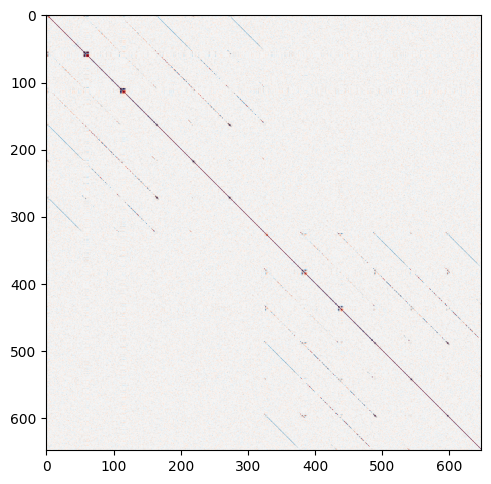

In [10]:
plt.figure(figsize=(5, 5))
corr = null_archive.cov / np.sqrt(np.outer(np.diag(null_archive.cov), np.diag(null_archive.cov)))
plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.tight_layout()

The above correlation matrix is computed from all residuals listed by the `inspect()` method above. You can always apply filters using the `select()` method.

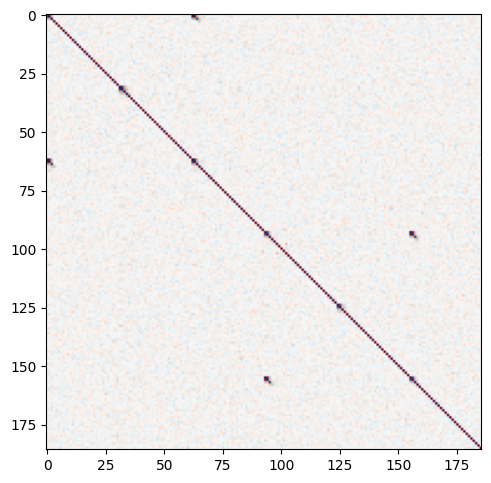

In [15]:
mask = null_archive.select(field_pairs=["EE", "EB", "BB"], ellmin=30, ellmax=500)
cov = null_archive.cov[np.ix_(mask, mask)]
corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))
plt.figure(figsize=(5, 5))
plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.tight_layout()

This method is used internally to select subsets of the data to provide specific summary statistics.

Let's now have a look at some power spectra residuals.

(100.0, 500.0)

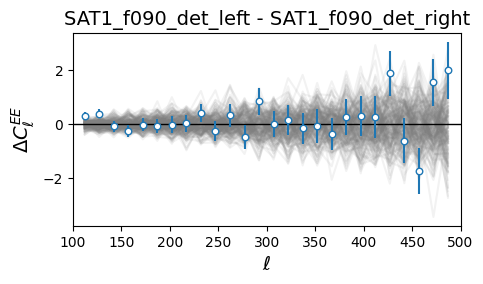

In [39]:
mapA = "SAT1_f090_det_left"
mapB = "SAT1_f090_det_right"
field_pair = "EE"

x, y, ycov = null_archive.get_ps_residual(
    mapA,
    mapB,
    field_pair=field_pair
)
mask = (x >= 100) & (x <= 500)
plt.figure(figsize=(5, 2.5))
plt.xlabel(r"$\ell$", fontsize=14)
plt.ylabel(r"$\Delta C_\ell^{%s}$" % field_pair, fontsize=14)
plt.title(f"{mapA} - {mapB}", fontsize=14)
plt.axhline(0, color="k", lw=1)
plt.errorbar(
    x[mask], y[mask], yerr=np.sqrt(np.diag(ycov))[mask],
    marker="o",
    markersize=4.7,
    markerfacecolor="white",
    ls="None",
    zorder=5
)

# It also works for simulations!!!
for iii in null_archive.sim_ids:
    x, y, _ = null_archive.get_ps_residual(
        mapA,
        mapB,
        field_pair=field_pair,
        sim_id=iii
    )
    plt.plot(x[mask], y[mask], color="gray", alpha=0.1, zorder=0)
plt.xlim(100, 500)

Finally, the `NullArchive` class provides a method to generate a pre-defined set of summary statistics.

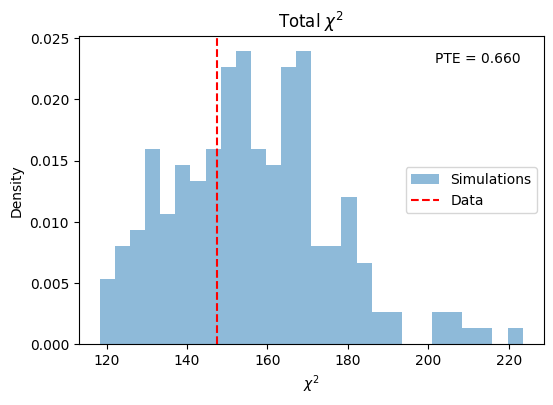

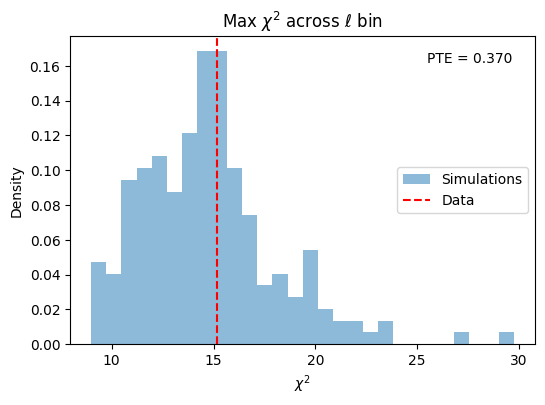

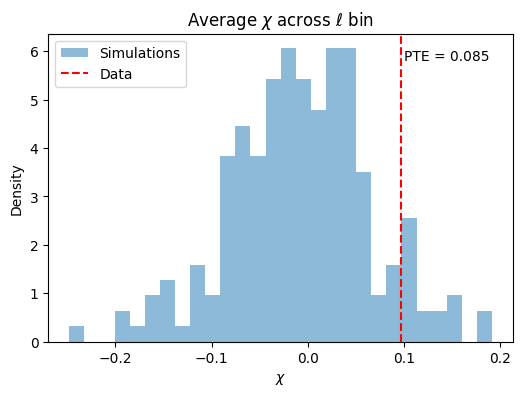

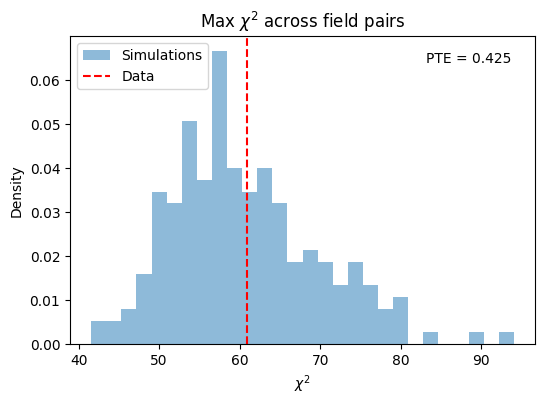

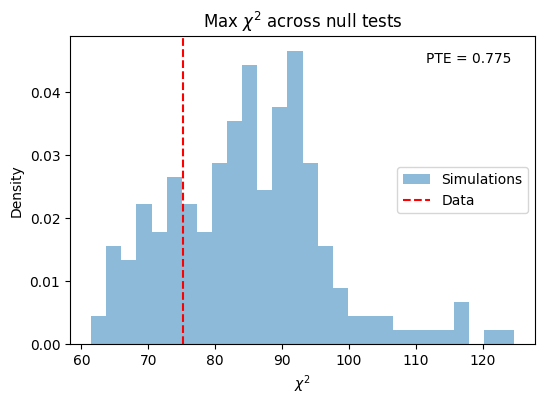

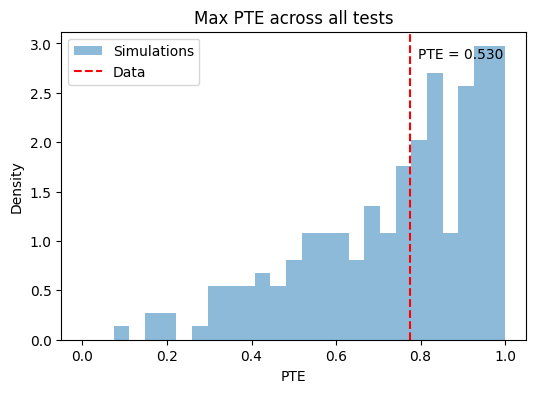

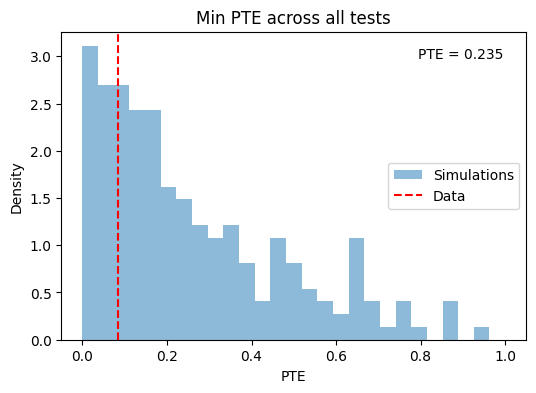

In [40]:
null_archive.summary_stats(
    null_groups=None, # Allnull groups will be included
    field_pairs=["EE", "EB", "BB"], # Focus on polarization
    ellmin=100,
    ellmax=500,
    diag_cov=True,
    display=True
)